In [1]:
from google.colab import userdata
import os

# Retrieve the Hugging Face token from Colab secrets
hf_token = userdata.get('HF_TOKEN')
#print(hf_token)

# Set the Hugging Face token as an environment variable
os.environ['HF_TOKEN'] = hf_token


In [2]:
!pip install transformers==4.39.3

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 160.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 73.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 149.3 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.7.1
    Uninstalling huggingface_hub-1.7.1:
      Successfully uninstalled huggingface_hub-1.7.1
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.2
    Uninstalling tokenizers-0.22.2:
      Successfully uninstalled tokenizers-0.22.2
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the foll

In [7]:
import torch
from transformers import AutoConfig, AutoModelForCausalLM
import matplotlib.pyplot as plt



In [8]:
class H2OKVCache:
    def __init__(self, cache_budget=1024, n_sink=4, n_recent=256):
        self.cache_budget = cache_budget
        self.n_sink       = n_sink
        self.n_recent     = n_recent
        self.n_heavy      = cache_budget - n_sink - n_recent
        assert self.n_heavy > 0, "Cache budget too small"

        self.attn_scores  = None   # scores for currently kept tokens only
        self.kept_indices = None   # original token positions still in cache

    def reset(self):
        self.attn_scores  = None
        self.kept_indices = None

    def update(self, attn_weights):
        """
        attn_weights: [batch, heads, query_len, key_len]
        key_len = number of tokens currently being attended to (before eviction)
        Returns: number of tokens in cache after this step
        """
        # Average attention across batch, heads, query positions → [key_len]
        new_scores = attn_weights.mean(dim=(0, 1, 2)).cpu()
        current_seq_len = new_scores.shape[0]   # total tokens seen so far

        if self.kept_indices is None:
            # Very first step — accept all tokens
            self.kept_indices = list(range(current_seq_len))
            self.attn_scores  = new_scores.clone()
        else:
            # new_scores has shape [current_seq_len]
            # self.kept_indices tells us which of those positions are in cache
            # Accumulate only for positions we're tracking
            for local_i, orig_i in enumerate(self.kept_indices):
                if orig_i < current_seq_len:
                    self.attn_scores[local_i] += new_scores[orig_i]

            # Add the brand-new token (last position) to cache
            new_token_idx = current_seq_len - 1
            self.kept_indices.append(new_token_idx)
            self.attn_scores = torch.cat([
                self.attn_scores,
                new_scores[new_token_idx].unsqueeze(0)
            ])

        # No eviction needed yet
        if len(self.kept_indices) <= self.cache_budget:
            return len(self.kept_indices)

        # ── Eviction: work entirely in local index space ──────────────────
        n = len(self.kept_indices)

        sink_local   = list(range(self.n_sink))
        recent_local = list(range(n - self.n_recent, n))
        protected    = set(sink_local + recent_local)

        # Score the middle (evictable) tokens
        middle_local  = [i for i in range(n) if i not in protected]
        middle_scored = sorted(middle_local,
                               key=lambda i: self.attn_scores[i].item(),
                               reverse=True)   # highest score = keep

        heavy_local = middle_scored[:self.n_heavy]
        keep_local  = sorted(set(sink_local + heavy_local + recent_local))

        # Update both structures using the same local indices
        self.kept_indices = [self.kept_indices[i] for i in keep_local]
        self.attn_scores  = self.attn_scores[torch.tensor(keep_local)]

        return len(self.kept_indices)

=== H2O (cache budget = 1024 tokens) ===
  seq_len=  512 | cache tokens=  512 | size=0.0671 GB
  seq_len= 1024 | cache tokens= 1024 | size=0.1342 GB
  seq_len= 2048 | cache tokens= 1024 | size=0.1342 GB
  seq_len= 4096 | cache tokens= 1024 | size=0.1342 GB
  seq_len= 8192 | cache tokens= 1024 | size=0.1342 GB


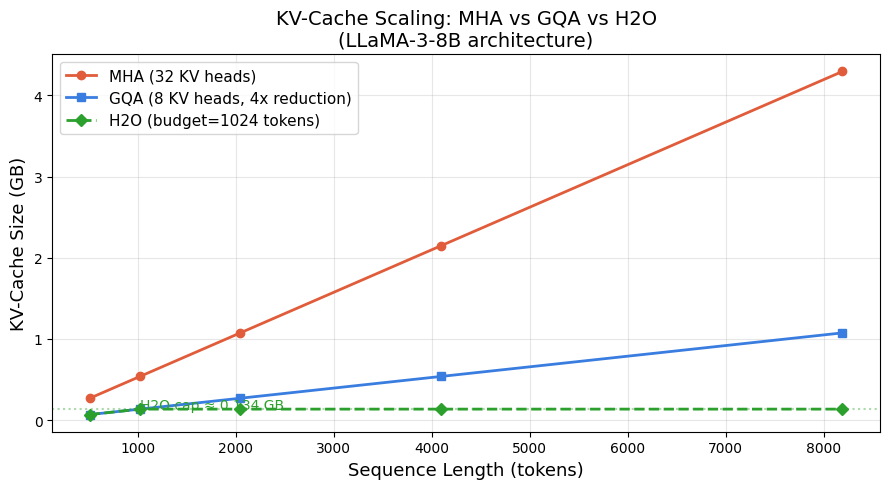

Saved kv_cache_all_methods.png


In [9]:
# ─────────────────────────────────────────────
# LOAD CONFIG (no weights needed)
# ─────────────────────────────────────────────

model_name = "meta-llama/Meta-Llama-3-8B"
config = AutoConfig.from_pretrained(model_name)

seq_lengths  = [512, 1024, 2048, 4096, 8192]
cache_budget = 1024  # H2O hard cap

# ── Theoretical MHA and GQA sizes ────────────────────────────────────────────
def theoretical_kv_gb(config, seq_len, num_kv_heads):
    head_dim = config.hidden_size // config.num_attention_heads
    return (config.num_hidden_layers * 2 * seq_len *
            num_kv_heads * head_dim * 2) / 1e9

mha_sizes = [theoretical_kv_gb(config, s, config.num_attention_heads) for s in seq_lengths]
gqa_sizes = [theoretical_kv_gb(config, s, config.num_key_value_heads) for s in seq_lengths]

# ── Updated H2O measurement (matches new update() signature) ─────────────────
def measure_h2o_cache_size(config, seq_lengths, cache_budget,
                            n_sink=4, n_recent=256):
    num_layers   = config.num_hidden_layers
    num_kv_heads = config.num_key_value_heads
    head_dim     = config.hidden_size // config.num_attention_heads
    bytes_per_el = 2  # FP16

    h2o = H2OKVCache(cache_budget=cache_budget, n_sink=n_sink, n_recent=n_recent)
    sizes_gb = []

    for seq_len in seq_lengths:
        h2o.reset()

        for step in range(seq_len):
            # Simulate attention: [batch=1, heads, query=1, key=step+1]
            attn_w = torch.softmax(
                torch.randn(1, num_kv_heads, 1, step + 1), dim=-1
            )
            cache_tokens = h2o.update(attn_w)  # ← no seq_len arg

        total_bytes = (num_layers * 2 * cache_tokens *
                       num_kv_heads * head_dim * bytes_per_el)
        size_gb = total_bytes / 1e9
        sizes_gb.append(size_gb)
        print(f"  seq_len={seq_len:>5} | cache tokens={cache_tokens:>5} "
              f"| size={size_gb:.4f} GB")

    return sizes_gb

print("=== H2O (cache budget = 1024 tokens) ===")
h2o_sizes = measure_h2o_cache_size(config, seq_lengths, cache_budget=cache_budget)

# ─────────────────────────────────────────────
# PLOT — All 3 methods on one chart
# ─────────────────────────────────────────────

plt.figure(figsize=(9, 5))
plt.plot(seq_lengths, mha_sizes, 'o-',  color='#e05c3a', linewidth=2, label='MHA (32 KV heads)')
plt.plot(seq_lengths, gqa_sizes, 's-',  color='#3a7de0', linewidth=2, label='GQA (8 KV heads, 4x reduction)')
plt.plot(seq_lengths, h2o_sizes, 'D--', color='#2ca02c', linewidth=2, label=f'H2O (budget={cache_budget} tokens)')

# Annotate H2O flatline
plt.axhline(y=max(h2o_sizes), color='#2ca02c', linestyle=':', alpha=0.4)
plt.text(seq_lengths[1], max(h2o_sizes) * 1.05,
         f'H2O cap ≈ {max(h2o_sizes):.3f} GB', color='#2ca02c', fontsize=10)

plt.xlabel("Sequence Length (tokens)", fontsize=13)
plt.ylabel("KV-Cache Size (GB)", fontsize=13)
plt.title("KV-Cache Scaling: MHA vs GQA vs H2O\n(LLaMA-3-8B architecture)", fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("kv_cache_all_methods.png", dpi=150)
plt.show()
print("Saved kv_cache_all_methods.png")
